# Merge ML EDA — Can a simple model beat thresholds?

Loads features from **canonical runs** (one per source dataset), trains LR / DT / RF,
uses SHAP to find top features. Use `eda_merge_explore.ipynb` first to sanity-check data.

**Spec**: `specs/016-merge-eda-validation/spec.md`

**Key principle**: Features should measure the **distance relationship** between two
clusters — not properties of the dataset. `t_local`/`t_global` are run-level constants
that leak run identity into the model; they are excluded.

**Empirical observation**: `p10_cross_dist ≈ 0.60` appears to be the key separator —
pairs where the 10th-percentile cross-cluster distance is below ~0.60 have strong
overlap evidence and tend to be merges. A p10 threshold alone is a strong baseline;
the model's job is to capture the cases where other signals (geometry, size, margin)
override the simple p10 rule.

**Feature groups used**:
- Distance distribution: `min_exemplar_dist`, `p10/p25/p50_cross_dist`, `support_fraction`, `cross_dist_iqr`
- Merge consequences: `post_merge_diameter`, `diameter_expansion`
- Cluster geometry (per-pair, not per-run): `size_a/b`, `size_ratio`, `mean_intra_dist_a/b`
- Anti-merge: `same_image_min_dist`
- Derived ratios: `p10_over_p50` (distribution shape), `inter_over_intra` (margin signal)

**Data quality:**
- One canonical run per source dataset (no duplicates)
- Union-find transitive closure for merge labels
- Human labels from training_db override heuristic labels
- By-run CV to test cross-album generalization

In [138]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

from face_cluster.loader import load_pipeline_result
from face_cluster.features import FeatureComputer, MergeFeatureContext
from face_cluster.training_db import load_training_data

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)

# --- Project root (two levels up from notebooks/face_clustering/) ---
PROJECT_ROOT = Path("../../")
RESULTS_DIR = PROJECT_ROOT / "results"

## 1. Load features from canonical runs (one per source dataset)

Each source album has many result directories (reclusters, parameter sweeps). We use
exactly one canonical run per album — the one with the most merge activity.

In [ ]:
# Pipeline default — must match face_cluster/config.py merge_candidate_threshold.
CANDIDATE_THRESHOLD = 0.45

# Features that measure the relationship between two clusters.
# All vary per pair (not per run). t_local/t_global excluded — they are run-level
# constants that leak run identity into the model.
DISTANCE_FEATURES = [
    # Cross-cluster distance distribution
    "min_exemplar_dist",          # best-case distance between representative faces
    "p10_exemplar_dist",          # 10th-percentile of exemplar-to-exemplar distances
    "p25_exemplar_dist",          # 25th-percentile of exemplar-to-exemplar distances
    "exemplar_dist_mean",         # average exemplar-to-exemplar distance
    "min_cross_dist",             # absolute closest pair
    "p10_cross_dist",             # near-side (~0.60 empirical threshold)
    "p25_cross_dist",             # lower quartile
    "p50_cross_dist",             # median cross-cluster distance
    "cross_dist_iqr",             # spread of the distribution
    "support_fraction",           # fraction of cross-pairs below threshold (breadth)
    # Merge consequences
    "post_merge_diameter",        # how big the merged cluster would be
    "diameter_expansion",         # relative growth: post_merge / max(dia_a, dia_b)
    # Cluster geometry — vary per pair, not per run
    "size_a", "size_b",           # raw cluster sizes
    "size_ratio",                 # size_min / size_max — asymmetry
    "mean_intra_dist_a",          # intra-cluster compactness A
    "mean_intra_dist_b",          # intra-cluster compactness B
    # Anti-merge signal
    "same_image_min_dist",        # same source photo -> different people
    # Derived ratio features (added after loading, see cell below)
    "p10_over_p50",               # distribution shape: near-tail / median
    "inter_over_intra",           # margin signal: p10 / max intra-dist
    # Gate-pass features: ConservativeMerger gates (derived in cell below)
    # Gate C (margin vs next-best cluster) is excluded — not a per-pair feature.
    "gate_a_pass",                # exemplar dist <= merge_exemplar_threshold (0.35)
    "gate_b_pass",                # support count >= required (frac * min_size, min=2)
    "gate_d_pass",                # post_merge_diameter <= diameter_max * 1.5
    "n_gates_passed",             # sum of gate_a + gate_b + gate_d (max=3)
]

# Canonical runs loaded from configs/label_runs.csv — single source of truth
# shared with the Label Verification tab. Edit the CSV, not this dict.
import csv as _csv
_label_runs_csv = PROJECT_ROOT / "configs" / "label_runs.csv"
CANONICAL_RUNS = {}
with open(_label_runs_csv, newline="", encoding="utf-8") as _f:
    for _row in _csv.DictReader(_f):
        if _row.get("enabled", "1").strip() in ("1", "true", "yes"):
            CANONICAL_RUNS[_row["dataset"].strip()] = _row["run_id"].strip()
print(f"Canonical runs loaded from CSV: {list(CANONICAL_RUNS)}")


# --- Union-find for transitive closure ---
class UnionFind:
    def __init__(self):
        self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb


def load_run_features(run_dir, run_id=None):
    """Load and compute features for one canonical run.

    Args:
        run_dir:  Path to the run directory.
        run_id:   Key used to store/look up labels in training_db. Must match
                  the run_id written by the Label Verification tab (i.e., the
                  full relative run name like "shira_album1/base", not just
                  run_dir.name which would give "base").
                  Defaults to run_dir.name when not provided.
    """
    result = load_pipeline_result(run_dir)
    cr = result.cluster_result
    if len(cr.clusters) < 2:
        return pd.DataFrame()
    # Distance matrix
    embs = []
    for f in result.faces:
        e = f.embedding_normalized if f.embedding_normalized is not None else f.embedding
        embs.append(e / (np.linalg.norm(e) + 1e-9) if e is not None
                    else np.zeros(512, dtype=np.float32))
    mat = np.stack(embs).astype(np.float32)
    dm = np.clip(1.0 - mat @ mat.T, 0.0, 2.0)
    # Features
    ctx = MergeFeatureContext(cluster_result=cr, faces=result.faces,
                             distance_matrix=dm, graph_result=None)
    fc = FeatureComputer()
    pf = fc.compute_all_pairs(ctx, candidate_threshold=CANDIDATE_THRESHOLD)
    if not pf:
        return pd.DataFrame()
    df = fc.to_dataframe(pf)
    df["run_id"] = run_id if run_id is not None else run_dir.name

    # Label using transitive closure
    ml_path = run_dir / "merge_log.json"
    if not ml_path.exists():
        df["label"] = 0
        return df
    ml = json.loads(ml_path.read_text())
    uf = UnionFind()
    for entry in ml:
        if entry["action"] == "merged":
            uf.union(entry["cluster_a"], entry["cluster_b"])
    df["label"] = df.apply(
        lambda r: 1 if uf.find(int(r["cluster_a"])) == uf.find(int(r["cluster_b"])) else 0,
        axis=1,
    )
    return df


# Load from canonical runs only
print("Loading canonical runs:")
canonical_dirs = []
for ds_name, run_name in CANONICAL_RUNS.items():
    rd = RESULTS_DIR / run_name
    if rd.exists():
        canonical_dirs.append((ds_name, rd, run_name))
        print(f"  {ds_name:20s} -> {run_name}")
    else:
        print(f"  {ds_name:20s} -> MISSING: {rd}")

In [ ]:
# ---------------------------------------------------------------------------
# Data source — choose one mode:
#
#   "db"       : Load features + human labels from training_db (SQLite).
#                Best for model training. Requires Label Verification tab
#                to have been run for each canonical run first.
#
#   "run_dir"  : Load features from candidate_pairs.parquet saved automatically
#                after each clustering run. No labels — best for what-if
#                threshold analysis on a single run.
# ---------------------------------------------------------------------------
DATA_SOURCE = "db"          # "db" or "run_dir"
RUN_DIR = None              # e.g. RESULTS_DIR / "Germany_12"  (only used when DATA_SOURCE="run_dir")

from face_cluster.export import load_candidate_pairs

def _load_from_db() -> pd.DataFrame:
    df = load_training_data()
    if df.empty:
        print("ERROR: DB is empty.")
        print("Open the Label Verification tab and click Load Dataset for each canonical run first.")
        return df
    enabled_run_ids = set(CANONICAL_RUNS.values())
    df = df[df["run_id"].isin(enabled_run_ids)].copy()
    source_col = df.get("source", pd.Series("heuristic", index=df.index))
    is_human_ignore = (source_col == "human") & df["label"].isna()
    df = df[~is_human_ignore].copy()
    df = df[df["label"].notna()].copy()
    df["label"] = df["label"].astype(int)
    return df


def _load_from_run_dir(run_dir: Path) -> pd.DataFrame:
    df = load_candidate_pairs(run_dir)
    if df is None:
        print(f"ERROR: candidate_pairs.parquet not found in {run_dir}")
        print("Re-run clustering on this run to generate it (pipeline auto-saves after exemplars stage).")
        return pd.DataFrame()
    df["run_id"] = run_dir.name
    # No labels in candidate_pairs — add NaN column so downstream cells don't crash
    if "label" not in df.columns:
        df["label"] = np.nan
    return df


# --- Load ---
if DATA_SOURCE == "db":
    df_all = _load_from_db()
elif DATA_SOURCE == "run_dir":
    assert RUN_DIR is not None, "Set RUN_DIR to the run folder path when DATA_SOURCE='run_dir'"
    df_all = _load_from_run_dir(Path(RUN_DIR))
else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}. Use 'db' or 'run_dir'.")

# --- Summary ---
if not df_all.empty:
    run_to_ds = {v: k for k, v in CANONICAL_RUNS.items()}
    has_labels = df_all["label"].notna().any()
    print(f"Loaded {len(df_all)} pairs from {df_all['run_id'].nunique()} run(s)  "
          f"[source={DATA_SOURCE}, labels={'yes' if has_labels else 'no'}]")
    for run_id, grp in df_all.groupby("run_id"):
        ds = run_to_ds.get(run_id, run_id)
        lbl_counts = grp["label"].value_counts(dropna=True).to_dict()
        src_counts = grp.get("source", pd.Series()).value_counts().to_dict()
        print(f"  {ds} [{run_id}]: {len(grp)} pairs  labels={lbl_counts}  sources={src_counts}")
    display(df_all[["run_id", "cluster_a", "cluster_b", "label",
                     "min_exemplar_dist", "p10_exemplar_dist", "p25_exemplar_dist",
                     "p10_cross_dist"]].head(10))

In [144]:
print("Label distribution by run:")
for run_id, grp in df_all.groupby("run_id"):
    dist = grp["label"].value_counts().to_dict()
    print(f"  {run_id}: {dist}")


Label distribution by run:
  Austria24_1: {1: 120, 0: 10}
  Germany_12: {1: 35, 0: 15}
  Noa2-5: {0: 1}
  Noa5-7: {1: 7, 0: 2}
  shira_album1/base: {1: 68, 0: 46}


In [145]:
# --- Derived ratio features (computed from raw features, no backend changes needed) ---
# Must run before the feature filtering cell below.

# p10_over_p50: near-tail / median.
#   Low ratio = distribution is left-heavy = many pairs are close = strong evidence.
#   High ratio = only a thin tail of close pairs = weaker evidence.
df_all["p10_over_p50"] = (
    df_all["p10_cross_dist"] / df_all["p50_cross_dist"].replace(0, np.nan)
).clip(0, 2)

# inter_over_intra: p10 / max intra-cluster spread.
#   The classic "margin" signal: are these clusters closer to each other
#   than they are internally? Ratio < 1.0 = yes, strong overlap.
df_all["intra_max"] = df_all[["mean_intra_dist_a", "mean_intra_dist_b"]].max(axis=1)
df_all["inter_over_intra"] = (
    df_all["p10_cross_dist"] / df_all["intra_max"].replace(0, np.nan)
).clip(0, 5)

print("Derived features added. Median by label:")
for feat in ["p10_over_p50", "inter_over_intra"]:
    medians = df_all.groupby("label")[feat].median().to_dict()
    print(f"  {feat}: Reject={medians.get(0, 'n/a'):.3f}  Merge={medians.get(1, 'n/a'):.3f}")

Derived features added. Median by label:
  p10_over_p50: Reject=0.916  Merge=0.894
  inter_over_intra: Reject=1.705  Merge=1.456


In [166]:
# --- Gate-pass features (derived from existing features, no backend changes needed) ---
# Mirrors ConservativeMerger._evaluate_merge_evidence() with default config values.
# See face_cluster/config.py and face_cluster/merge.py for the authoritative logic.
#
# Gate A: min exemplar distance <= merge_exemplar_threshold
# Gate B: n_cross_pairs_below_threshold >= max(min(size_a,size_b)*frac, min_count)
# Gate C: margin to next-best cluster — EXCLUDED. Requires global context (distance
#         to all other clusters), not available as a per-pair feature in the DB.
# Gate D: post_merge_diameter <= max(dia_a, dia_b) * expansion_factor

MERGE_EXEMPLAR_THRESHOLD   = 0.55   # config.merge_exemplar_threshold
MERGE_SUPPORT_FRAC         = 0.30   # config.merge_support_frac
MERGE_SUPPORT_MIN          = 2      # config.merge_support_min
DIAMETER_EXPANSION_FACTOR  = 1.5    # config.merge_diameter_expansion_factor

# Gate A: exemplar distance gate
df_all["gate_a_pass"] = (df_all["min_exemplar_dist"] <= MERGE_EXEMPLAR_THRESHOLD).astype(int)

# Gate B: support count gate
df_all["_size_min"] = df_all[["size_a", "size_b"]].min(axis=1)
_required_support = (df_all["_size_min"] * MERGE_SUPPORT_FRAC).clip(lower=MERGE_SUPPORT_MIN)
df_all["gate_b_pass"] = (df_all["n_cross_pairs_below_threshold"] >= _required_support).astype(int)
df_all.drop(columns=["_size_min"], inplace=True)

# Gate D: post-merge diameter gate
df_all["gate_d_pass"] = (
    df_all["post_merge_diameter"] <= df_all["diameter_max"] * DIAMETER_EXPANSION_FACTOR
).astype(int)

# n_gates_passed: sum of available gates (max=3; Gate C excluded)
df_all["n_gates_passed"] = df_all["gate_a_pass"] + df_all["gate_b_pass"] + df_all["gate_d_pass"]

print("Gate feature distribution by label (1=pass, 0=fail):")
for gate in ["gate_a_pass", "gate_b_pass", "gate_d_pass", "n_gates_passed"]:
    stats = df_all.groupby("label")[gate].mean().to_dict()
    print(f"  {gate:20s}: Reject mean={stats.get(0, 'n/a'):.2f}  Merge mean={stats.get(1, 'n/a'):.2f}")

print()
print("n_gates_passed counts by label:")
print(df_all.groupby(["label", "n_gates_passed"]).size().unstack(fill_value=0))

Gate feature distribution by label (1=pass, 0=fail):
  gate_a_pass         : Reject mean=0.26  Merge mean=0.78
  gate_b_pass         : Reject mean=0.00  Merge mean=0.00
  gate_d_pass         : Reject mean=0.45  Merge mean=0.53
  n_gates_passed      : Reject mean=0.70  Merge mean=1.31

n_gates_passed counts by label:
n_gates_passed   0   1    2  3
label                         
0               34  28   12  0
1               37  85  107  1


In [ ]:
# --- Re-estimate n_cross_pairs at a different threshold using stored percentiles ---
#
# n_cross_pairs_below_threshold was stored at support_threshold=0.35 (FeatureComputer default).
# The stored percentiles give us a CDF:
#   (min_cross_dist, 0%), (p10, 10%), (p25, 25%), (p50, 50%), (p75, 75%), (p90, 90%)
# plus the exact stored point at 0.35 (support_fraction).
# Piecewise-linear interpolation between these anchors gives a good estimate at any threshold.
#
# Limitation: above p90_cross_dist the CDF clamps at 90% (no upper bound stored).
#   If new_thresh >> p90 this will underestimate. Use load_run_features() for exact values.

ORIGINAL_SUPPORT_THRESHOLD = 0.35   # threshold used when features were stored in the DB

def estimate_support_at_threshold(df: pd.DataFrame, new_thresh: float) -> pd.Series:
    """Estimate n_cross_pairs_below_threshold at a new threshold via CDF interpolation.

    Uses piecewise-linear interpolation over (min, p10, p25, p50, p75, p90) anchors,
    plus the exact stored point at 0.35. Returns an integer Series aligned to df.index.
    """
    dist_cols = ["min_cross_dist", "p10_cross_dist", "p25_cross_dist",
                 "p50_cross_dist", "p75_cross_dist", "p90_cross_dist"]
    frac_anchors = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90])

    n_total = (df["size_a"] * df["size_b"]).values
    sub = df[dist_cols + ["support_fraction"]].values  # shape (n_rows, 7)

    results = []
    for i, row in enumerate(sub):
        d_pts = list(row[:6])          # distance values at the 6 quantiles
        f_pts = list(frac_anchors)     # corresponding fractions
        sf = row[6]                    # stored support_fraction at 0.35
        if not np.isnan(sf):
            d_pts.append(ORIGINAL_SUPPORT_THRESHOLD)
            f_pts.append(float(sf))
            order = np.argsort(d_pts)  # np.interp requires xp increasing
            d_pts = np.array(d_pts)[order]
            f_pts = np.array(f_pts)[order]
        frac = float(np.interp(new_thresh, d_pts, f_pts))
        results.append(int(round(frac * n_total[i])))

    return pd.Series(results, index=df.index, name="n_cross_pairs_est")


# --- Choose the threshold you want to explore ---
NEW_SUPPORT_THRESHOLD = 0.45   # <-- edit this

df_all["n_cross_pairs_est"] = estimate_support_at_threshold(df_all, NEW_SUPPORT_THRESHOLD)

# Recompute Gate B at the new threshold
_size_min = df_all[["size_a", "size_b"]].min(axis=1)
_req = (_size_min * MERGE_SUPPORT_FRAC).clip(lower=MERGE_SUPPORT_MIN)
df_all["gate_b_pass_est"] = (df_all["n_cross_pairs_est"] >= _req).astype(int)

# Update n_gates_passed to use the estimated Gate B
df_all["n_gates_passed_est"] = df_all["gate_a_pass"] + df_all["gate_b_pass_est"] + df_all["gate_d_pass"]

print(f"Gate B comparison: stored (thresh=0.35) vs estimated (thresh={NEW_SUPPORT_THRESHOLD})")
comp = df_all.groupby("label")[["gate_b_pass", "gate_b_pass_est", "n_gates_passed", "n_gates_passed_est"]].mean()
display(comp.rename(index={0: "Reject", 1: "Merge"}).round(3))

print(f"\nn_gates_passed_est counts by label (thresh={NEW_SUPPORT_THRESHOLD}):")
print(df_all.groupby(["label", "n_gates_passed_est"]).size().unstack(fill_value=0))

In [160]:
df_all.columns

Index(['id', 'run_id', 'album_path', 'cluster_a', 'cluster_b', 'label',
       'feature_version', 'output_dir', 'exemplar_ids', 'saved_at', 'source',
       'verified', 'min_exemplar_dist', 'exemplar_dist_mean',
       'exemplar_dist_std', 'min_cross_dist', 'p10_cross_dist',
       'p25_cross_dist', 'p50_cross_dist', 'p75_cross_dist', 'p90_cross_dist',
       'cross_dist_iqr', 'support_fraction', 'n_cross_pairs_below_threshold',
       'size_a', 'size_b', 'size_min', 'size_ratio', 'size_sum', 'diameter_a',
       'diameter_b', 'diameter_max', 'diameter_ratio', 'post_merge_diameter',
       'diameter_expansion', 'mean_intra_dist_a', 'mean_intra_dist_b',
       'exemplar_count_a', 'exemplar_count_b', 't_a', 't_b', 't_local',
       't_global', 'dist_to_threshold_ratio', 'n_images_a', 'n_images_b',
       'shared_source_images', 'shared_source_ratio', 'same_image_min_dist',
       'mean_blur_a', 'mean_blur_b', 'blur_min_a', 'blur_min_b',
       'frontal_frac_a', 'frontal_frac_b', 'frontal

In [158]:
import seaborn as sns

In [163]:
df_all['label'].value_counts()

label
1    230
0     74
Name: count, dtype: int64

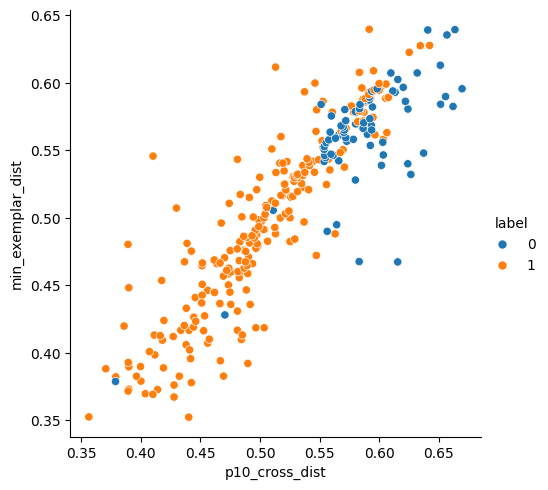

In [164]:
sns.relplot(x='p10_cross_dist', y='min_exemplar_dist', data=df_all, hue='label')

## 1b. Restrict to distance-only features

We drop dataset-property features (`t_local`, `t_global`, blur, pose, area, sizes)
and keep only features that measure the relationship between the two clusters.

In [147]:
# Filter to distance-only features
available_dist = [f for f in DISTANCE_FEATURES if f in df_all.columns]
dropped = [c for c in df_all.columns
           if c not in available_dist and c not in ["cluster_a", "cluster_b", "run_id", "label"]]

print(f"Using {len(available_dist)} distance features: {available_dist}")
print(f"Dropped {len(dropped)} non-distance features: {dropped[:10]}{'...' if len(dropped) > 10 else ''}")

# Correlation with label
corr_label = df_all[available_dist + ["label"]].corr()["label"].drop("label").abs().sort_values(ascending=False)
print(f"\nDistance features ranked by |correlation with label|:")
display(corr_label.to_frame("abs_corr"))

Using 22 distance features: ['min_exemplar_dist', 'exemplar_dist_mean', 'min_cross_dist', 'p10_cross_dist', 'p25_cross_dist', 'p50_cross_dist', 'cross_dist_iqr', 'support_fraction', 'post_merge_diameter', 'diameter_expansion', 'size_a', 'size_b', 'size_ratio', 'mean_intra_dist_a', 'mean_intra_dist_b', 'same_image_min_dist', 'p10_over_p50', 'inter_over_intra', 'gate_a_pass', 'gate_b_pass', 'gate_d_pass', 'n_gates_passed']
Dropped 43 non-distance features: ['id', 'album_path', 'feature_version', 'output_dir', 'exemplar_ids', 'saved_at', 'source', 'verified', 'exemplar_dist_std', 'p75_cross_dist']...

Distance features ranked by |correlation with label|:


,abs_corr
same_image_min_dist,0.570115
p10_cross_dist,0.541056
p25_cross_dist,0.537855
p50_cross_dist,0.508306
exemplar_dist_mean,0.504237
min_exemplar_dist,0.428851
min_cross_dist,0.408301
post_merge_diameter,0.261142
inter_over_intra,0.227362
p10_over_p50,0.199597


## 2. Balance and prepare

Two CV strategies:
- **Stratified 5-fold**: standard, but pairs from the same run can appear in both train and test
- **Group (by-run) 5-fold**: each run is entirely in train or test — tests generalization to unseen albums

In [148]:
META = ["cluster_a", "cluster_b", "run_id", "label"]
df_bal = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

usable = [c for c in available_dist if c in df_bal.columns and df_bal[c].notna().any()]
X = df_bal[usable].copy()
for c in usable:
    X[c] = X[c].fillna(X[c].median())
y = df_bal["label"].values.astype(int)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Simple 80/20 train/test split (stratified by label)
X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_tr)} samples  Test: {len(X_te)} samples  "
      f"({int(y_tr.sum())} pos / {int((y_tr==0).sum())} neg train, "
      f"{int(y_te.sum())} pos / {int((y_te==0).sum())} neg test)")
print(f"Features: {len(usable)}  Total samples: {len(df_bal)}")

Train: 243 samples  Test: 61 samples  (183 pos / 60 neg train, 47 pos / 14 neg test)
Features: 22  Total samples: 304


## 3. Train models (5-fold CV)

Run with stratified CV first, then with by-run CV to check if the model generalizes
across albums or just memorizes within-run patterns.

In [149]:
models = [
    ("LR", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("DT(d=4)", DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)),
    ("RF(200)", RandomForestClassifier(n_estimators=200, max_depth=8,
                                       class_weight="balanced", random_state=42, n_jobs=-1)),
]

results = {}
for name, model in models:
    model.fit(X_tr, y_tr)
    yp = model.predict(X_te)
    yprob = model.predict_proba(X_te)[:, 1]
    results[name] = (yp, yprob)
    print(f"\n=== {name} ===")
    print(classification_report(y_te, yp, labels=[0,1], target_names=["Reject", "Merge"], zero_division=0))
    if len(set(y_te)) > 1:
        print(f"AUC: {roc_auc_score(y_te, yprob):.3f}")
    else:
        print("AUC: n/a (only one class in test set)")


=== LR ===
              precision    recall  f1-score   support

      Reject       0.50      0.57      0.53        14
       Merge       0.87      0.83      0.85        47

    accuracy                           0.77        61
   macro avg       0.68      0.70      0.69        61
weighted avg       0.78      0.77      0.78        61

AUC: 0.847

=== DT(d=4) ===
              precision    recall  f1-score   support

      Reject       0.58      0.79      0.67        14
       Merge       0.93      0.83      0.88        47

    accuracy                           0.82        61
   macro avg       0.75      0.81      0.77        61
weighted avg       0.85      0.82      0.83        61

AUC: 0.866

=== RF(200) ===
              precision    recall  f1-score   support

      Reject       0.62      0.57      0.59        14
       Merge       0.88      0.89      0.88        47

    accuracy                           0.82        61
   macro avg       0.75      0.73      0.74        61
weight

In [150]:
# DT rules (interpretable)
dt = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
dt.fit(X_tr, y_tr)
print(export_text(dt, feature_names=usable, max_depth=3))

|--- p10_cross_dist <= 0.41
|   |--- p50_cross_dist <= -2.73
|   |   |--- class: 0
|   |--- p50_cross_dist >  -2.73
|   |   |--- p50_cross_dist <= 0.93
|   |   |   |--- class: 1
|   |   |--- p50_cross_dist >  0.93
|   |   |   |--- post_merge_diameter <= 1.07
|   |   |   |   |--- class: 0
|   |   |   |--- post_merge_diameter >  1.07
|   |   |   |   |--- class: 1
|--- p10_cross_dist >  0.41
|   |--- p50_cross_dist <= 1.33
|   |   |--- min_exemplar_dist <= 1.41
|   |   |   |--- size_b <= -0.09
|   |   |   |   |--- class: 0
|   |   |   |--- size_b >  -0.09
|   |   |   |   |--- class: 1
|   |   |--- min_exemplar_dist >  1.41
|   |   |   |--- class: 1
|   |--- p50_cross_dist >  1.33
|   |   |--- p10_over_p50 <= -1.17
|   |   |   |--- class: 1
|   |   |--- p10_over_p50 >  -1.17
|   |   |   |--- exemplar_dist_mean <= 0.78
|   |   |   |   |--- class: 1
|   |   |   |--- exemplar_dist_mean >  0.78
|   |   |   |   |--- class: 0



## 4. Feature importance — RF Gini + SHAP

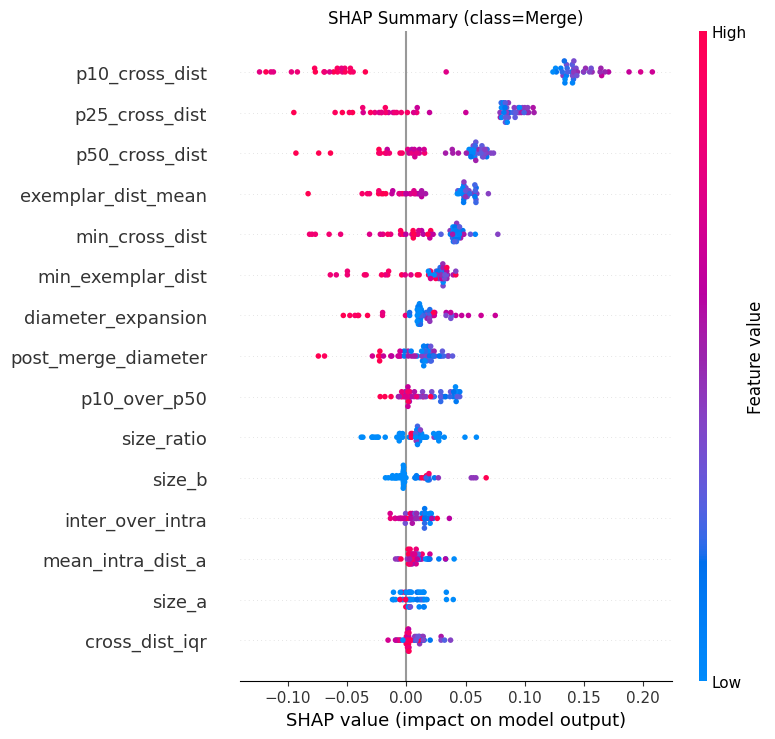

In [151]:
rf_full = RandomForestClassifier(n_estimators=200, max_depth=8,
                                  class_weight="balanced", random_state=42, n_jobs=-1)
rf_full.fit(X_tr, y_tr)

# SHAP
explainer = shap.TreeExplainer(rf_full)
sv_raw = explainer.shap_values(X_te)
sv = sv_raw[:, :, 1] if sv_raw.ndim == 3 else (sv_raw[1] if isinstance(sv_raw, list) else sv_raw)

shap.summary_plot(sv, X_te, feature_names=usable, max_display=15, show=False)
plt.title("SHAP Summary (class=Merge)")
plt.tight_layout()
plt.show()

In [152]:
# Top features by mean |SHAP|
shap_imp = pd.DataFrame({"feature": usable, "shap": np.abs(sv).mean(axis=0)})
shap_imp = shap_imp.sort_values("shap", ascending=False)
TOP = shap_imp.head(3)["feature"].tolist()
print(f"Top 3 features: {TOP}")
display(shap_imp.head(10))

Top 3 features: ['p10_cross_dist', 'p25_cross_dist', 'p50_cross_dist']


,feature,shap
3,p10_cross_dist,0.118448
4,p25_cross_dist,0.064198
5,p50_cross_dist,0.043139
1,exemplar_dist_mean,0.035233
2,min_cross_dist,0.034412
0,min_exemplar_dist,0.028073
9,diameter_expansion,0.022006
8,post_merge_diameter,0.019017
16,p10_over_p50,0.018100
12,size_ratio,0.015762


## 5. Top features vs label

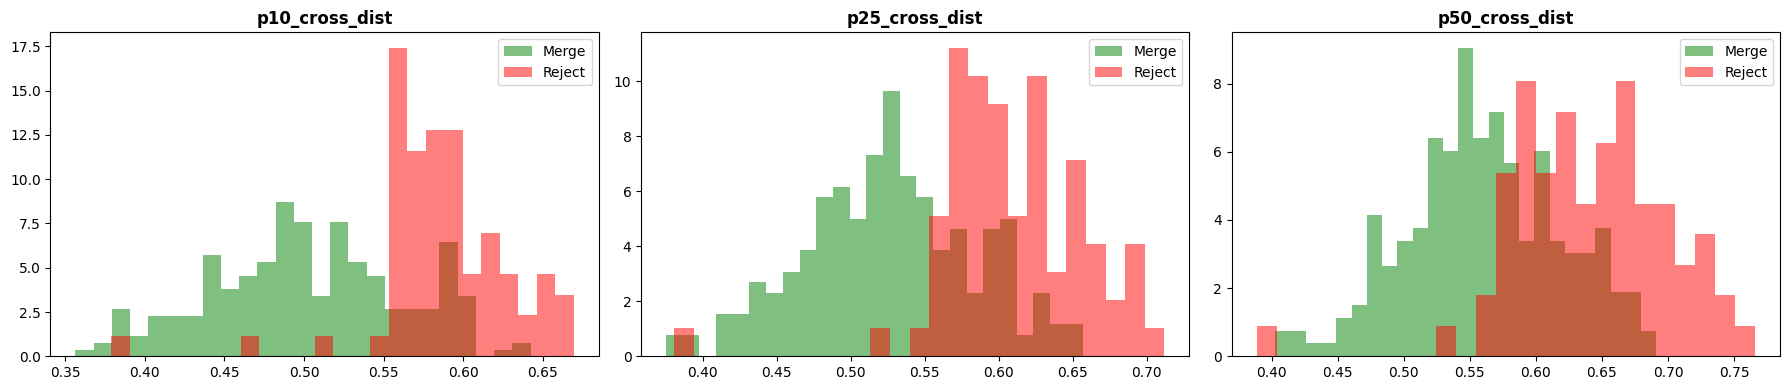

In [153]:
# Histograms
fig, axes = plt.subplots(1, len(TOP), figsize=(6 * len(TOP), 4))
for ax, feat in zip(axes, TOP):
    for label, color, name in [(1, "green", "Merge"), (0, "red", "Reject")]:
        ax.hist(df_bal[df_bal["label"] == label][feat].dropna(),
                bins=25, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(feat, fontweight="bold")
    ax.legend()
fig.tight_layout()
plt.show()

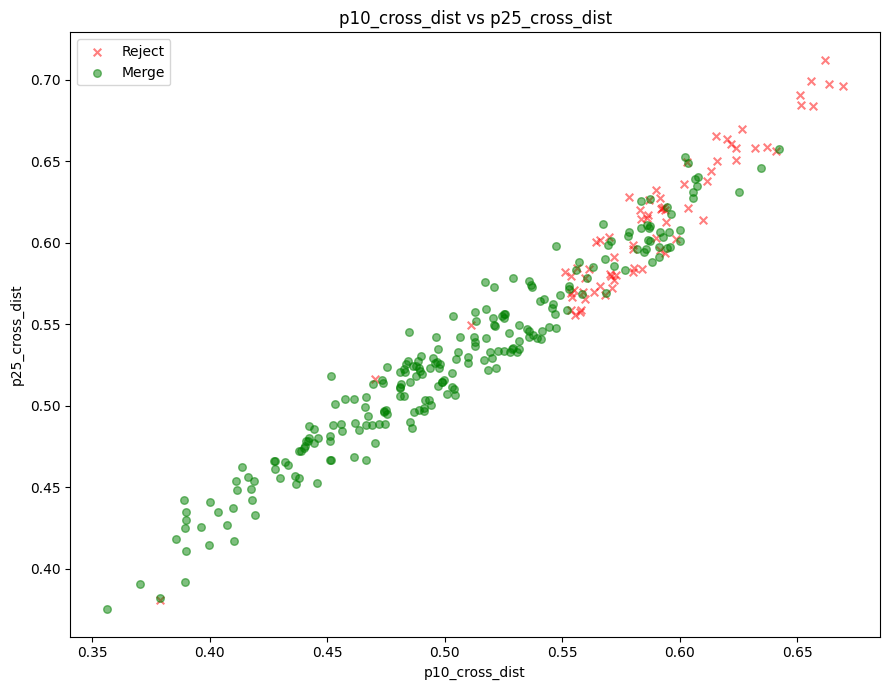

In [154]:
# Scatter: top 2 features
if len(TOP) >= 2:
    fig, ax = plt.subplots(figsize=(9, 7))
    for label, color, marker, name in [(0, "red", "x", "Reject"), (1, "green", "o", "Merge")]:
        sub = df_bal[df_bal["label"] == label]
        ax.scatter(sub[TOP[0]], sub[TOP[1]], c=color, marker=marker, alpha=0.5, label=name, s=30)
    ax.set_xlabel(TOP[0])
    ax.set_ylabel(TOP[1])
    ax.set_title(f"{TOP[0]} vs {TOP[1]}")
    ax.legend()
    fig.tight_layout()
    plt.show()

## 6. Confusion matrix + comparison vs best threshold

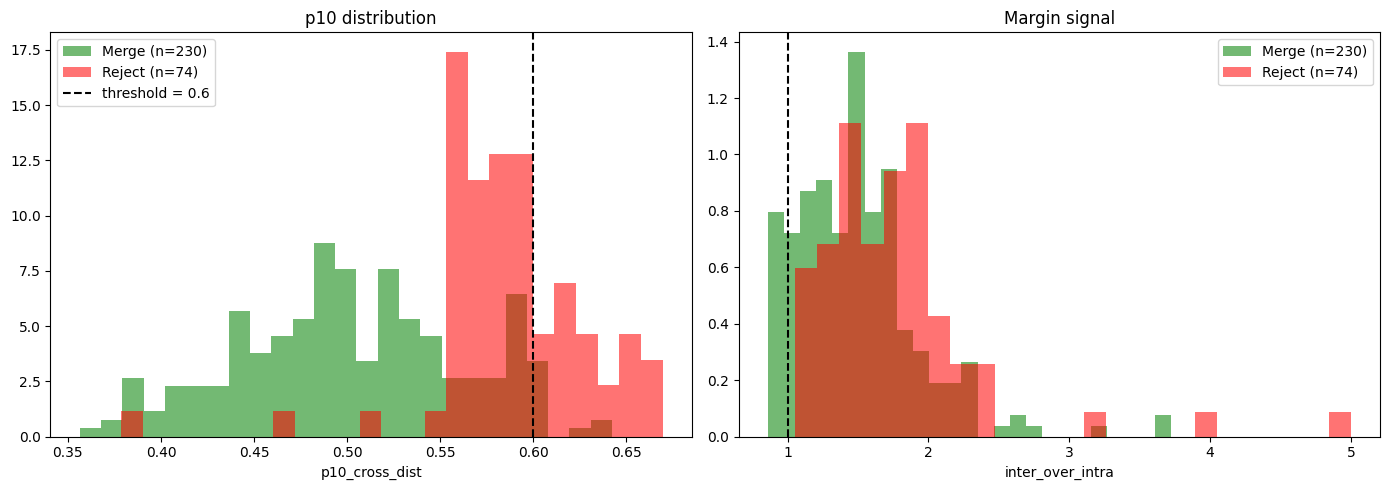

p10 < 0.6 (empirical):  F1 = 0.816
p10 < 0.66  (sweep best):   F1 = 0.870
RF(200):                         F1 = 0.884  (delta: +0.014)


In [155]:
# --- p10 threshold analysis ---
P10_THRESHOLD = 0.60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(1, "green", "Merge"), (0, "red", "Reject")]:
    vals = df_bal[df_bal["label"] == label]["p10_cross_dist"].dropna()
    if len(vals):
        axes[0].hist(vals, bins=25, alpha=0.55, color=color,
                     label=f"{name} (n={len(vals)})", density=True)
axes[0].axvline(P10_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
                label=f"threshold = {P10_THRESHOLD}")
axes[0].set_xlabel("p10_cross_dist")
axes[0].set_title("p10 distribution")
axes[0].legend()

if "inter_over_intra" in df_bal.columns:
    for label, color, name in [(1, "green", "Merge"), (0, "red", "Reject")]:
        vals = df_bal[df_bal["label"] == label]["inter_over_intra"].dropna()
        if len(vals):
            axes[1].hist(vals, bins=25, alpha=0.55, color=color,
                         label=f"{name} (n={len(vals)})", density=True)
    axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1.5)
    axes[1].set_xlabel("inter_over_intra")
    axes[1].set_title("Margin signal")
    axes[1].legend()

fig.tight_layout()
plt.show()

# Threshold sweep on test set
te_p10 = df_bal.iloc[len(X_tr):]["p10_cross_dist"].values
best_f1, best_t = 0.0, P10_THRESHOLD
for t in np.arange(0.20, 1.00, 0.02):
    f = f1_score(y_te, (te_p10 < t).astype(int), zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t

p10_f1 = f1_score(y_te, (te_p10 < P10_THRESHOLD).astype(int), zero_division=0)
rf_f1  = f1_score(y_te, results["RF(200)"][0], zero_division=0)

print(f"p10 < {P10_THRESHOLD} (empirical):  F1 = {p10_f1:.3f}")
print(f"p10 < {best_t:.2f}  (sweep best):   F1 = {best_f1:.3f}")
print(f"RF(200):                         F1 = {rf_f1:.3f}  (delta: {rf_f1 - best_f1:+.3f})")


In [156]:
# RF confusion matrix
yp_rf, yprob_rf = results["RF(200)"]
cm = confusion_matrix(y_te, yp_rf, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
rf_f1 = f1_score(y_te, yp_rf, zero_division=0)
print(f"RF: TP={tp}  FP={fp}  TN={tn}  FN={fn}  F1={rf_f1:.3f}")

# Best single-threshold heuristic on min_exemplar_dist
best_f1, best_t = 0, 0
te_min_dist = df_bal.iloc[len(X_tr):]["min_exemplar_dist"].values
for t in np.arange(0.1, 1.0, 0.02):
    yh = (te_min_dist < t).astype(int)
    f = f1_score(y_te, yh, zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t
print(f"Best threshold heuristic: threshold={best_t:.2f}  F1={best_f1:.3f}")
print(f"Delta: RF F1 - heuristic F1 = {rf_f1 - best_f1:+.3f}")


RF: TP=42  FP=6  TN=8  FN=5  F1=0.884
Best threshold heuristic: threshold=0.60  F1=0.879
Delta: RF F1 - heuristic F1 = +0.006


## 7. Distance Feature Correlation + Redundancy

Check which distance features are redundant and which carry unique signal.

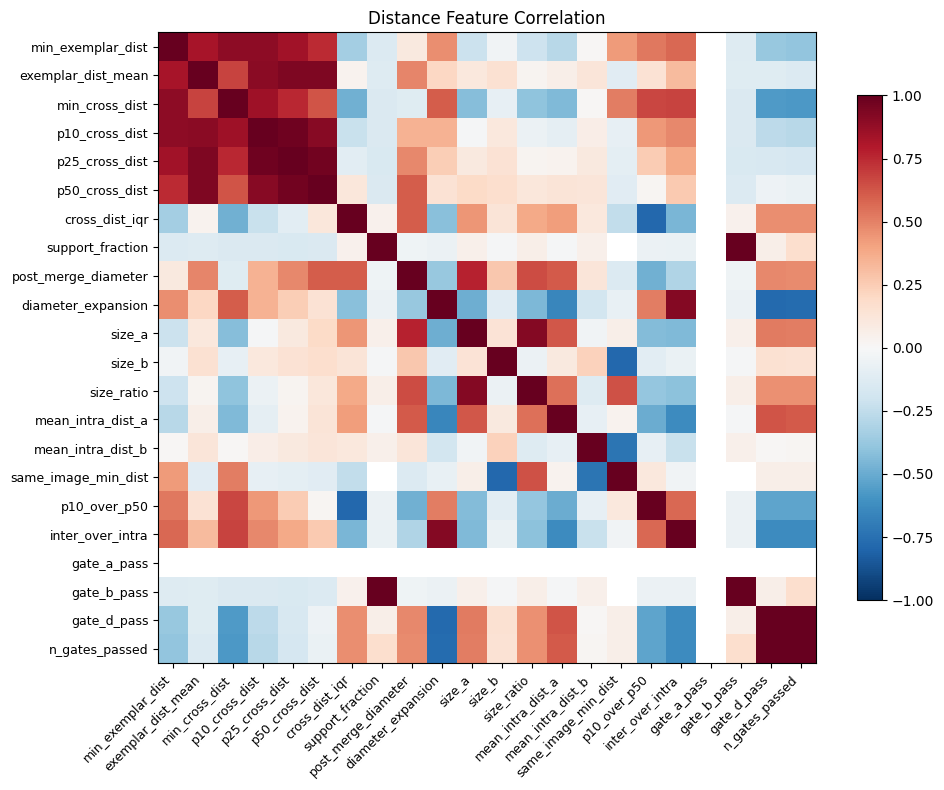

Highly correlated feature pairs (|r| > 0.9):
  exemplar_dist_mean <-> p10_cross_dist: r=0.906
  exemplar_dist_mean <-> p25_cross_dist: r=0.930
  exemplar_dist_mean <-> p50_cross_dist: r=0.937
  p10_cross_dist <-> p25_cross_dist: r=0.977
  p10_cross_dist <-> p50_cross_dist: r=0.910
  p25_cross_dist <-> p50_cross_dist: r=0.964
  support_fraction <-> gate_b_pass: r=0.999
  diameter_expansion <-> inter_over_intra: r=0.921
  size_a <-> size_ratio: r=0.919
  gate_d_pass <-> n_gates_passed: r=0.994

Final feature ranking by |correlation with label|:


,abs_corr
same_image_min_dist,0.570115
p10_cross_dist,0.541056
p25_cross_dist,0.537855
p50_cross_dist,0.508306
exemplar_dist_mean,0.504237
min_exemplar_dist,0.428851
min_cross_dist,0.408301
post_merge_diameter,0.261142
inter_over_intra,0.227362
p10_over_p50,0.199597


In [157]:
# Distance feature correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
cm = df_bal[usable].corr()
im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(usable)))
ax.set_yticks(range(len(usable)))
ax.set_xticklabels(usable, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(usable, fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Distance Feature Correlation")
fig.tight_layout()
plt.show()

# Flag redundant pairs
print("Highly correlated feature pairs (|r| > 0.9):")
for i, f1 in enumerate(usable):
    for f2 in usable[i+1:]:
        r = cm.loc[f1, f2]
        if abs(r) > 0.9:
            print(f"  {f1} <-> {f2}: r={r:.3f}")

# Correlation with label
corr_final = df_bal[usable + ["label"]].corr()["label"].drop("label").abs().sort_values(ascending=False)
print(f"\nFinal feature ranking by |correlation with label|:")
display(corr_final.to_frame("abs_corr"))